In [46]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path


variable2 = 'shelfmelt'
y2sec=-365.25*24*3600
factor = y2sec/10**12 #kg/s to GT/yr
pth = pth_helene

variable2 = 'iareafl'
factor = 1
pth = pth_helene

variable2 = 'iareagr'
factor = 1
pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/{variable2}/'
fname = f'{variable2}_'

In [47]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
spec_model_id = [ 'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] 
removeFileID = []
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
df_info_exp = df_info[df_info['Experiment']==exp].reset_index(drop =True)



In [48]:
## doe a model translaiton beca df+in model is not file id for MALI

In [49]:
df_info_exp

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,9,DOE,MALI,expAE05,UKESM,DOE\_MALI\_4km,DOE_MALI_1,True,Quad. Non-local,AntMean median,4km,2km,Floating condition,No melt,RO
2,14,DOE,MALI,expAE05,UKESM,DOE\_MALI\_8km\_Ant95,DOE_MALI_3,False,Quad. Non-local,AntMean 95th,8km,2km,Floating condition,No melt,RO
3,19,DOE,MALI,expAE05,UKESM,DOE\_MALI\_8km\_AntMean,DOE_MALI_2,False,Quad. Non-local,AntMean median,8km,2km,Floating condition,No melt,RO
4,24,IGE,Elmer/Ice,expAE05,UKESM,IGE\_ElmerIce,IGE_ElmerIce,True,PICO,custom,1km,0.5km,No,No melt,Fix
5,29,ILTS,SICOPOLIS,expAE05,UKESM,ILTS\_SICOPOLIS,ILTS_SICOPOLIS,True,Quad. Non-local,AntMean median,8km,8km,Floating condition,No melt,MH
6,34,IMAU,UFEMISM,expAE05,UKESM,IMAU\_UFEMISM1,IMAU_UFEMISM1,True,Quad. Local,custom,32km,16km,Floating condition,No melt,Fix
7,39,IMAU,UFEMISM,expAE05,UKESM,IMAU\_UFEMISM2,IMAU_UFEMISM2,False,Quad. Local,custom,32km,16km,Floating condition,No melt,Fix
8,44,IMAU,UFEMISM,expAE05,UKESM,IMAU\_UFEMISM3,IMAU_UFEMISM3,False,Quad. Local,custom,16km,8km,Floating condition,No melt,Fix
9,49,IMAU,UFEMISM,expAE05,UKESM,IMAU\_UFEMISM4,IMAU_UFEMISM4,False,Quad. Local,custom,16km,8km,Floating condition,No melt,Fix


In [50]:
df_info_exp.shape[0]//2

21

In [51]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
dic_area_of_interest['WestAntarctica'] = ['_region_1']
dic_area_of_interest['EastAntarctica'] = ['_region_2']
dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'                         
# regionnumbers = [2, 5, 6, 9, 11, 16]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode1']   = lst                             
                                
# regionnumbers = [1, 3, 4, 8, 18]
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode2']   = lst   

# regionnumbers = [ 7, 10, 12, 13, 14, 15,  17] 
# lst = []
# for r in regionnumbers:
#     lst.append(f'_sector_{r}')
# dic_area_of_interest['mode_rest']   = lst   

The path './figs/iareagr/' already exists.


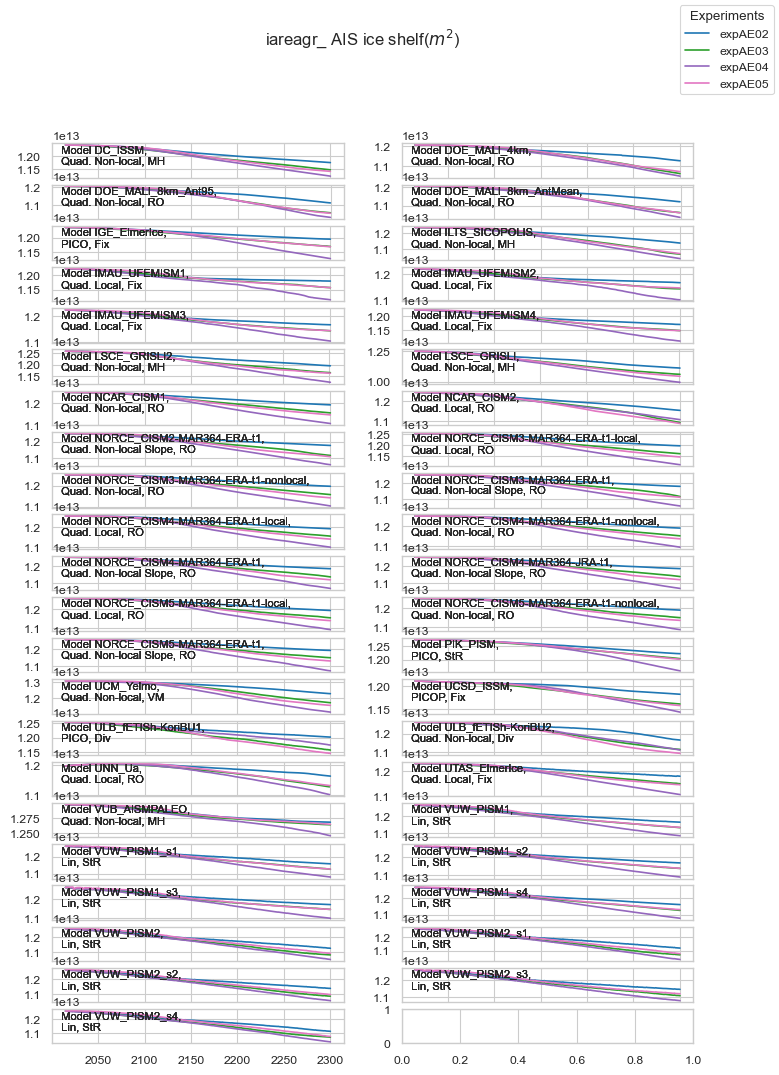

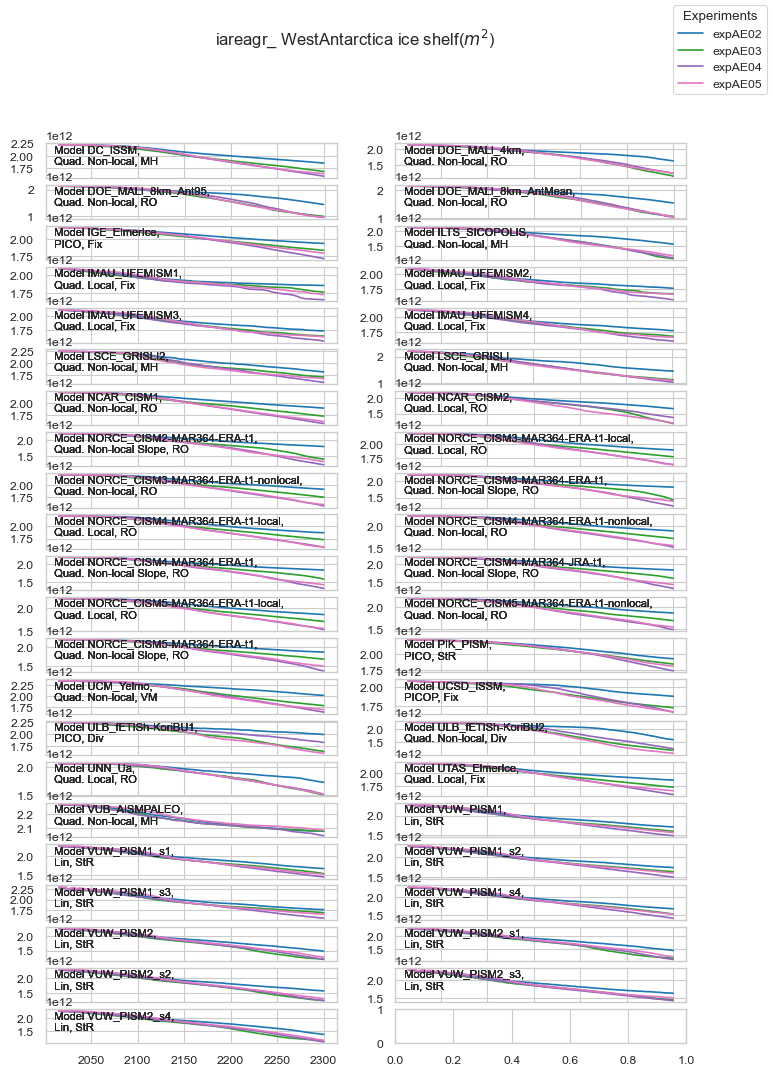

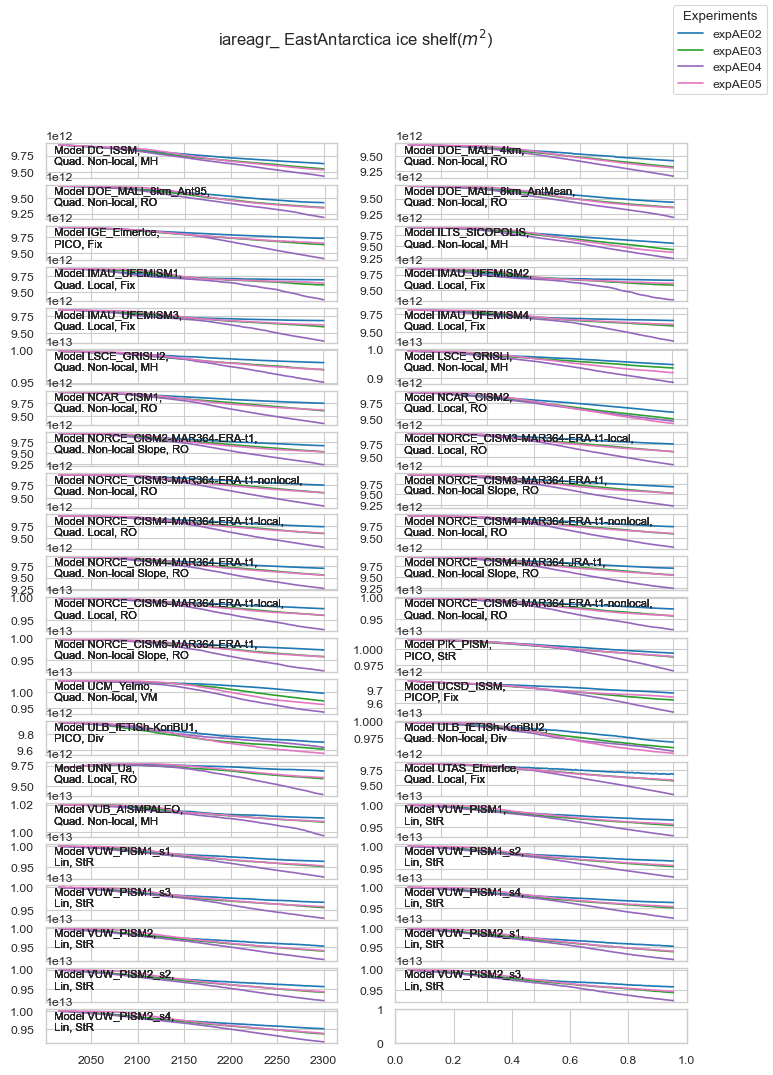

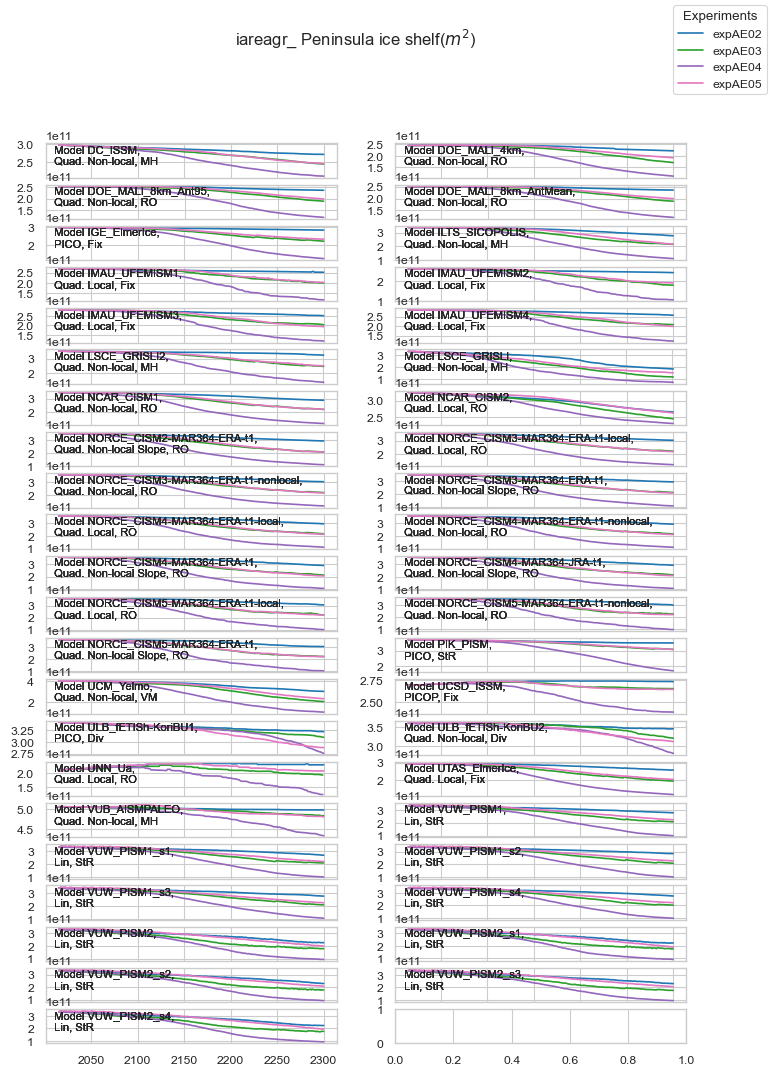

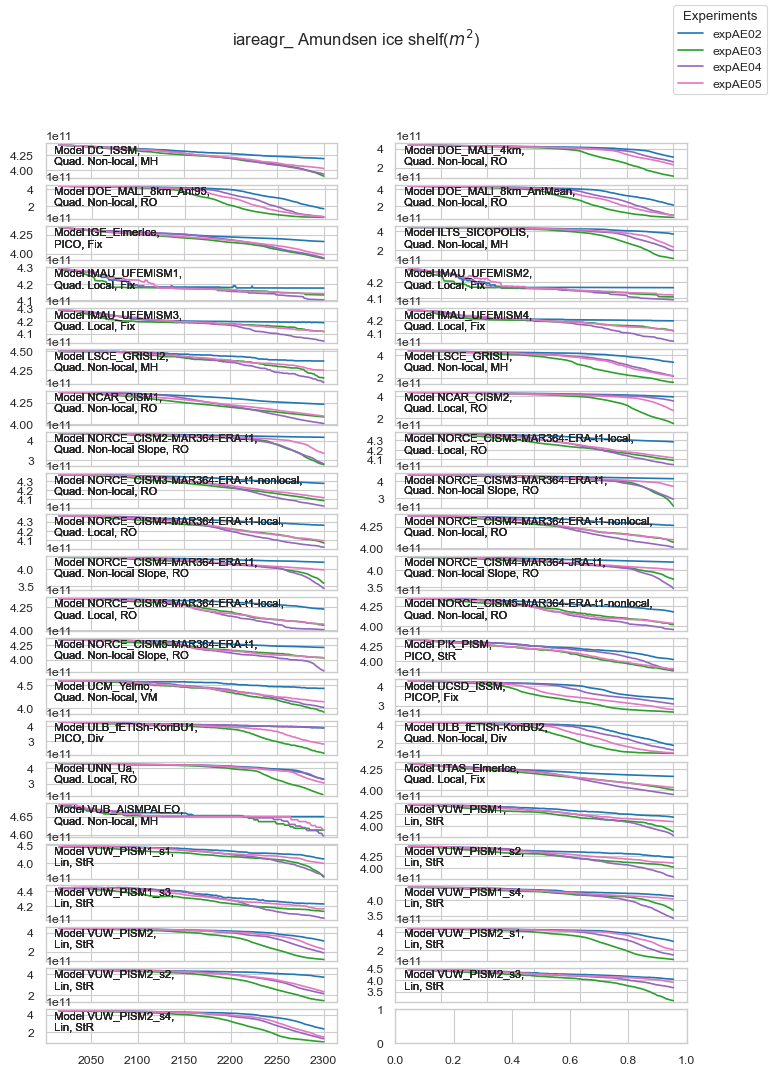

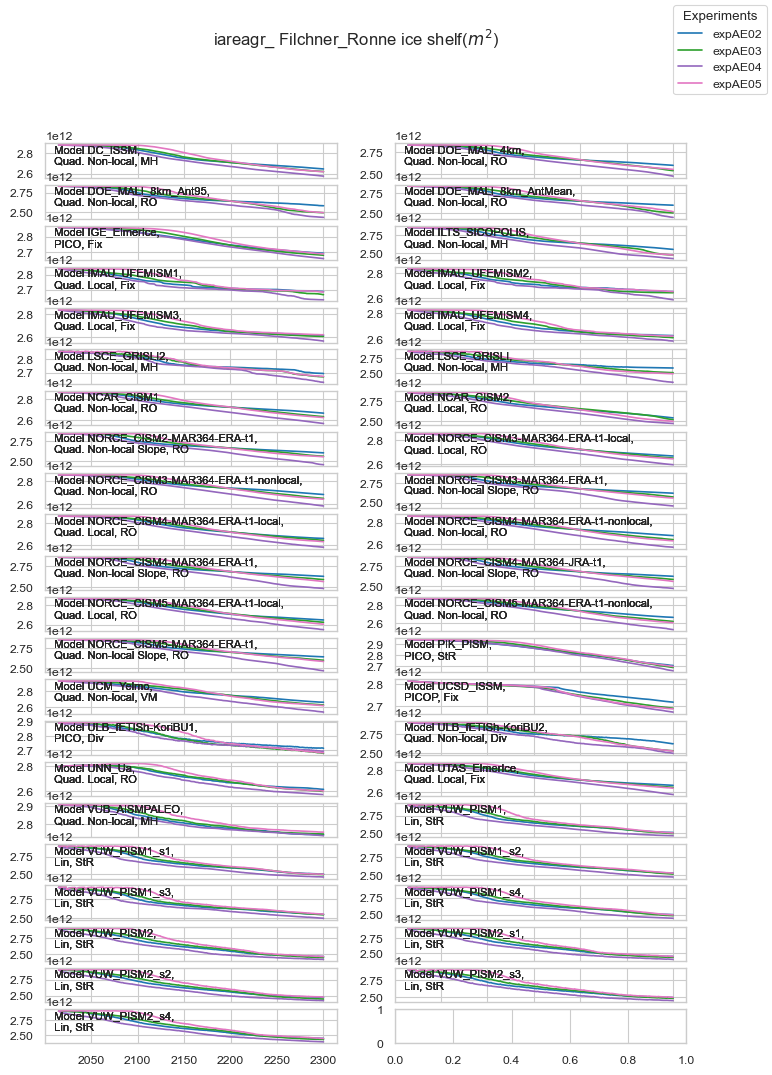

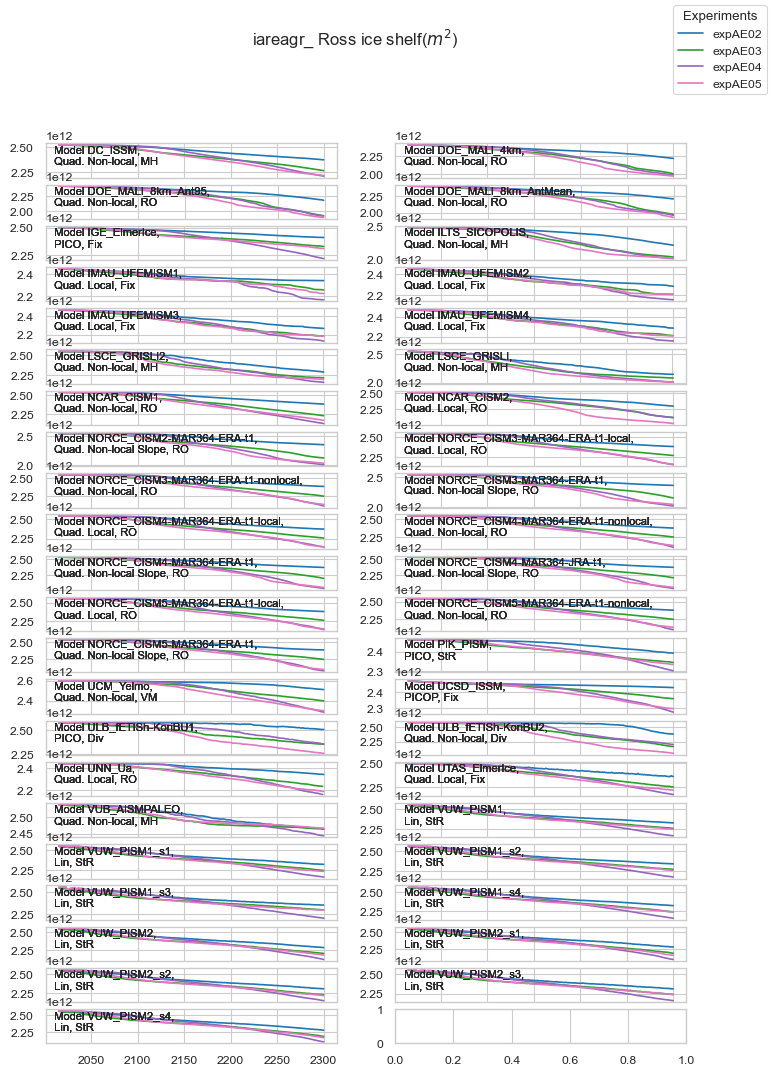

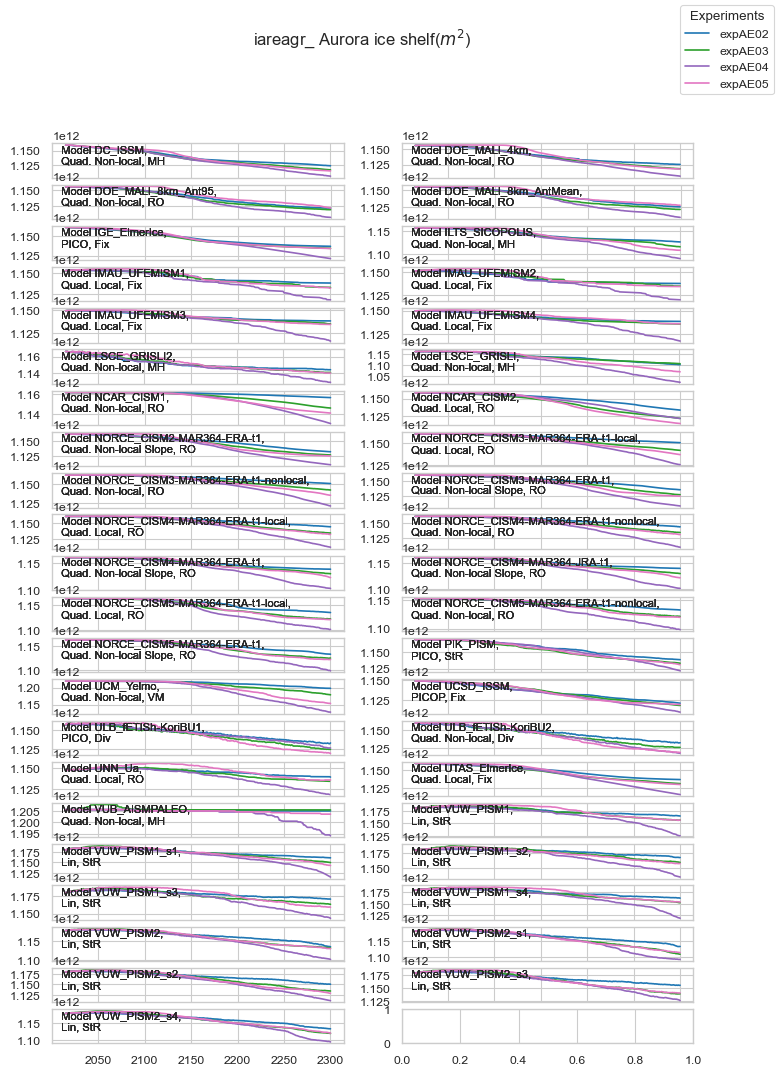

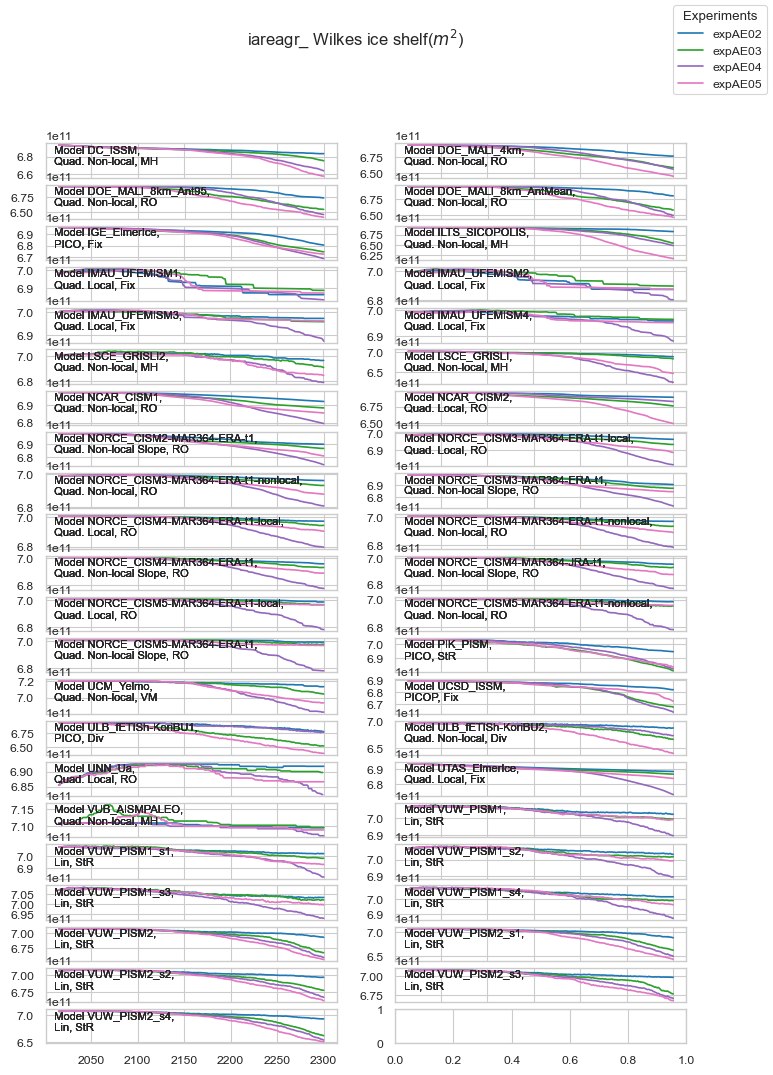

In [52]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")

for key in dic_area_of_interest.keys():
  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8
    regionnumbers = [2,6]
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    f,ax = plt.subplots(df.shape[0]//2+1,2,figsize=(a4_width, a4_height))
    for j,exp in enumerate(expnames):
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        for i in range (df.shape[0]):
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area

            pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'

       
            d3 = xr.open_dataset(pth_tf,decode_times=False )


            tmin = np.min([d3.time.size])
            #melting per area
            the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
          
            for k,nm in enumerate(lst):
                the_ys[k,:]= d3[f'{variable2}{nm}'].values[:tmin]*factor
                

            y = np.sum(the_ys ,axis =0)
            ax2 = ax[ix,iy]
            ax2.plot(d3.time[:tmin],y ,color = colors[j],label = f'{exp}')
            #model rename
            
            df_info_exp = df_info[df_info['Experiment']==exp]
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
            df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
#             df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]
            meltparam =  df_info_exp_model['Melt parameterisation'].values[0]
            icefront =  df_info_exp_model['ice front'].values[0]

            ax2.text(0.02, 0.98,f' Model {df.iloc[i].Model},\n {meltparam}, {icefront}',transform=ax2.transAxes,fontsize = fs, va='top')
    #         ax[ix, iy].text(0.02, 0.98, f'Experiment {exp} - Model {df.iloc[i].Model}', transform=ax[ix, iy].transAxes, fontsize=12, va='top')

    #         f.text(0.02, 0.98,
    handles, labels = ax[0, 0].get_legend_handles_labels()
    f.legend(handles, labels, loc='upper right', title='Experiments')

#     f.suptitle(f'{fname} {key} ice shelf(GT/yr)',fontsize = 12)
    f.suptitle(f'{fname} {key} ice shelf($m^2$)',fontsize = 12)
    
    f.savefig(f'{fpath}{fname}_{key}.pdf')
#     for j in range(1,19):

In [14]:
df.iloc[i].Model
# df.iloc[i].Path

'DOE_MALI_4km'

In [27]:
nmname 

'DC_ISSM'

In [23]:

    print('renamer')

renamer


In [15]:
            df_info_exp = df_info[df_info['Experiment']==exp]


In [21]:
renamer.keys()

dict_keys(['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'])

In [18]:
 df_info_exp

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
6,6,DOE,MALI,expAE02,CCSM4,DOE\_MALI\_4km,DOE_MALI_1,True,Quad. Non-local,AntMean median,4km,2km,Floating condition,No melt,RO
11,11,DOE,MALI,expAE02,CCSM4,DOE\_MALI\_8km\_Ant95,DOE_MALI_3,False,Quad. Non-local,AntMean 95th,8km,2km,Floating condition,No melt,RO
16,16,DOE,MALI,expAE02,CCSM4,DOE\_MALI\_8km\_AntMean,DOE_MALI_2,False,Quad. Non-local,AntMean median,8km,2km,Floating condition,No melt,RO
21,21,IGE,Elmer/Ice,expAE02,CCSM4,IGE\_ElmerIce,IGE_ElmerIce,True,PICO,custom,1km,0.5km,No,No melt,Fix
26,26,ILTS,SICOPOLIS,expAE02,CCSM4,ILTS\_SICOPOLIS,ILTS_SICOPOLIS,True,Quad. Non-local,AntMean median,8km,8km,Floating condition,No melt,MH
31,31,IMAU,UFEMISM,expAE02,CCSM4,IMAU\_UFEMISM1,IMAU_UFEMISM1,True,Quad. Local,custom,32km,16km,Floating condition,No melt,Fix
36,36,IMAU,UFEMISM,expAE02,CCSM4,IMAU\_UFEMISM2,IMAU_UFEMISM2,False,Quad. Local,custom,32km,16km,Floating condition,No melt,Fix
41,41,IMAU,UFEMISM,expAE02,CCSM4,IMAU\_UFEMISM3,IMAU_UFEMISM3,False,Quad. Local,custom,16km,8km,Floating condition,No melt,Fix
46,46,IMAU,UFEMISM,expAE02,CCSM4,IMAU\_UFEMISM4,IMAU_UFEMISM4,False,Quad. Local,custom,16km,8km,Floating condition,No melt,Fix


In [13]:
df_info.fileID

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,0,DC,ISSM,ctrlAE,ctrl,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
2,2,DC,ISSM,expAE03,HadGEM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
3,3,DC,ISSM,expAE04,CESM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
4,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,VUW,PISM,ctrlAE,ctrl,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
211,211,VUW,PISM,expAE02,CCSM4,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
212,212,VUW,PISM,expAE03,HadGEM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
213,213,VUW,PISM,expAE04,CESM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR


In [14]:
df_info['fileID'].values[0::5]

array(['DC_ISSM', 'DOE_MALI_1', 'DOE_MALI_3', 'DOE_MALI_2',
       'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'IMAU_UFEMISM1', 'IMAU_UFEMISM2',
       'IMAU_UFEMISM3', 'IMAU_UFEMISM4', 'LSCE_GRISLI', 'LSCE_GRISLI2',
       'NCAR_CISM1', 'NCAR_CISM2', 'NORCE_CISM2-MAR364-ERA-t1',
       'NORCE_CISM3-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM3-MAR364-ERA-t1-local', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM4-MAR364-ERA-t1-local', 'NORCE_CISM4-MAR364-JRA-t1',
       'NORCE_CISM5-MAR364-ERA-t1', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM5-MAR364-ERA-t1-local', 'PIK_PISM', 'UCM_Yelmo',
       'UCSD_ISSM', 'ULB_fETISh-KoriBU1', 'ULB_fETISh-KoriBU2', 'UNN_Ua',
       'UTAS_ElmerIce', 'VUB_AISMPALEO', 'VUW_PISM1', 'VUW_PISM1_s1',
       'VUW_PISM1_s2', 'VUW_PISM1_s3', 'VUW_PISM1_s4', 'VUW_PISM2',
       'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4'],
      dtype=object)

In [18]:
df_info


,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,0,DC,ISSM,ctrlAE,ctrl,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
2,2,DC,ISSM,expAE03,HadGEM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
3,3,DC,ISSM,expAE04,CESM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
4,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,VUW,PISM,ctrlAE,ctrl,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
211,211,VUW,PISM,expAE02,CCSM4,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
212,212,VUW,PISM,expAE03,HadGEM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
213,213,VUW,PISM,expAE04,CESM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
